In [1]:
#@title #1.Clone Github Repo

url = 'https://github.com/ultralytics/yolov5' #@param {type:"string"}
!git clone {url}
%cd {url.split('/')[-1]}

import utils
_ = utils.notebook_init()

YOLOv5 🚀 v6.1-259-ga2a1ed2 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)


Setup complete ✅ (4 CPUs, 25.5 GB RAM, 38.8/166.8 GB disk)


In [2]:
#@title #2.Library

%%capture

!python -m pip install rich
!pip install --upgrade --no-cache-dir gdown
!pip install -r requirements.txt
!pip install validators
!pip install alive-progress

import os
import cv2
import time
import gdown
import shutil
import random
import inspect
import zipfile
import datetime
import validators
import numpy as np
import collections
from tqdm import tqdm
from rich.table import Table
from google.colab import drive
from google.colab import files
from rich.console import Console
from IPython.display import Image
from alive_progress import alive_bar
from PIL.Image import open as image_open
from IPython.display import Markdown as md
from google.colab.patches import cv2_imshow

In [3]:
#@title # 3.Utils

drive.mount('/content/drive')

def get_latest_pretrained_model(pretrained_saved_path):
  pretrained_models = []
  for root, directories, files in os.walk(pretrained_saved_path):
    for file in files:
      if file.endswith(".pt"):
        pretrained_models.append((root, file))
  if len(pretrained_models) != 0:
    return os.path.join(pretrained_saved_path, sorted(pretrained_models)[-1][0], sorted(pretrained_models)[-1][1])
  else:
    return None

def new_path(root, folder_name):
  if root != None:
    return os.path.join(root, folder_name) 
  else:
    return folder_name

def create_new_folder(root=None):
  if root != None and not os.path.exists(root):
    os.makedir(root)
    
  paths = [new_path(root, "dataset"),
           
           new_path(root, "dataset/train"),
           new_path(root, "dataset/train/images"),
           new_path(root, "dataset/train/labels"),

           new_path(root, "dataset/val"),
           new_path(root, "dataset/val/images"),
           new_path(root, "dataset/val/labels"),
           
           new_path(root, "dataset/test"),
           new_path(root, "dataset/test/images"),
           new_path(root, "dataset/test/labels"),]
  
  for path in paths:
    if not os.path.exists(path):
      os.mkdir(path)

  return paths

def write_yaml():
  with open(PATH_CLASSES, "r") as classes_file:
    classes = []
    for item in classes_file.readlines():
      classes.append(item.strip())

    nc = f"nc: {len(classes)}\n"
    name = f"names: {str(classes)}"

  with open(PATH_DATA_YAML, "w") as data_file:
    data_file.write(f"train: {PATH_NEW_TRAIN_IMAGE}\n")
    data_file.write(f"val: {PATH_NEW_VAL_IMAGE}\n")
    data_file.write(nc)
    data_file.write(name)
  
  for line in open(PATH_DATA_YAML, "r").readlines():
    print(line, end="")
  
  print()

  return classes

def clean_dict(dictionary):
  delete_list = []
  for item in dictionary.items():
    if item[1] == 0:
      delete_list.append(item[0])

  for item in delete_list:
    del dictionary[item]

  return dictionary

def set_dict_defauft(classes):
  temp = collections.OrderedDict()
  for i in range(len(classes)):
      temp[str(i)] = 0
  return temp

def retrieve_name(var):
    callers_local_vars = inspect.currentframe().f_back.f_locals.items()
    return [var_name for var_name, var_val in callers_local_vars if var_val is var]

def get_label_file_info(classes, path_label, debug=None):
  if debug != None:
    print(f"GETTING LABELS INFORMATION of {debug}")
  labels_info = set_dict_defauft(classes)
  if any(isinstance(i, list) for i in path_label):
    for item in tqdm(path_label):
        with open(item[0], "r") as f:
            for line in f:
                labels_info[line.strip().split(" ")[0]] += 1
  
  elif type(path_label) == type(list()):
    for file in tqdm(path_label):
        with open(file, "r") as f:
            for line in f:
                labels_info[line.strip().split(" ")[0]] += 1

  elif os.path.isdir(path_label):
    for file in tqdm(os.listdir(path_label)):
        with open(os.path.join(path_label, file), "r") as f:
            for line in f:
                labels_info[line.strip().split(" ")[0]] += 1
    print()
  else:
    with open(os.path.join(path_label), "r") as f:
        for line in f:
            labels_info[line.strip().split(" ")[0]] += 1
  
  return labels_info

def get_files_absolue_path(path):
  data = []

  for root, directories, files in os.walk(path):
    for file in files:
      data.append(os.path.join(root, file))

  return data

def load_label_files(label_list):
  temp = []
  
  print(f"LOADING LABELS LIST {retrieve_name(label_list)[0]}")
  for file in tqdm(label_list):
      file_info = get_label_file_info(classes=classes, 
                                      path_label=file)
      temp.append([file, file_info])
  print()
  return temp

def find_image_file(path_images, label):
  name = ".".join(label.split(".")[:-1])
  for image in os.listdir(path_images):
    if name == ".".join(image.split(".")[:-1]):
      return os.path.join(path_images, image)

def get_file_list(classes, data, max, debug=None):
  final_class = set_dict_defauft(classes)
  final = []

  if debug != None:
    print(f"GETTTING DATASET FOR {debug}")

  for key in tqdm(range(len(classes))):
    temp = []
    """ Get file with key """
    for file in data:
      if file[1][str(key)] != 0:
        temp.append(file)

    """ Sort the list in ascending order by key """    
    # sorted_list = sorted(temp, key=lambda d: d[1][str(key)], reverse=True)
    sorted_list = sorted(temp, key=lambda d: (d[1][str(key)], d[0]), reverse=True)
    
    """ Choose images """
    for item in sorted_list:
      check = []
      for sorted_list_key in item[1].keys():
        if (final_class[str(sorted_list_key)] + item[1][sorted_list_key]) <= max and not item[0] in final:
            check.append(1)
        else:
          check.append(0)
      if 0 not in check:
        for sorted_list_key in item[1].keys():
          final_class[str(sorted_list_key)] += item[1][sorted_list_key]
        final.append(item)

  print()        
  return final

def relative_complement(list0, list1):
  return [x for x in list0 if x not in list1]

def split_dataset(classes, path_labels, portion, mode=0):
  if mode == 0:
    """ Getting Labels Information of all Labels"""
    labels_info = clean_dict(get_label_file_info(classes=classes,
                                                 path_label=path_labels,
                                                 debug=path_labels))

    """ Get the number of labels where the class has the lowest labels"""
    num_labels_class_least = labels_info[min(labels_info, key=labels_info.get)]

    """ Get Number of Files for Dataset """
    max_train = int(portion[0] * num_labels_class_least) + 1
    if portion[2] == 0:
      max_val = num_labels_class_least - max_train
      max_test = 0
    else:
      max_val = int(portion[1] * num_labels_class_least) + 1
      max_test = num_labels_class_least - max_train - max_val
    
    """ Get File List """
    temp_label_list = load_label_files(get_files_absolue_path(PATH_LABELS))
    
    train = get_file_list(classes=classes,
                          data=temp_label_list,
                          max=max_train,
                          debug='train')
    
    temp_label_list = relative_complement(temp_label_list, train)
    
    val = get_file_list(classes=classes,
                        data=temp_label_list,
                        max=max_val,
                        debug='val')
    if portion[2] == 0:
      test = []
    else:
      temp_label_list = relative_complement(temp_label_list, val)
    
      test = get_file_list(classes=classes,
                           data=temp_label_list,
                           max=max_test,
                           debug='test')

  return train, val, test

def copy_data(data, path_images, path_new_labels, path_new_images, debug):
  print(f"MOVING DATA OF {debug}")

  for item in tqdm(data):
      label_path = item[0]
      label_name = os.path.basename(label_path)
      new_label_path = os.path.join(path_new_labels, label_name)

      image_path = find_image_file(path_images=path_images,
                                   label=label_name)
      image_name = os.path.basename(image_path)
      new_image_path = os.path.join(path_new_images, image_name)

      shutil.copyfile(label_path, new_label_path)
      shutil.copyfile(image_path, new_image_path)
  print()

def add_background(data, destination, debug, portion=0.1,):
  new_portion = (portion * 100) / ((1-portion) * 100)
  num = int(len(os.listdir(destination)) * new_portion)
  if num > len(data):
    num = len(data)

  items_used = []
  print(f"ADDING BACKGROUND IMAGES TO {debug}")
  print(f"Nummber of backgounrd images: {num}")
  with alive_bar(num) as bar:
    for item in data:
      file_name = os.path.basename(item)
      file_new_path = os.path.join(destination, file_name)
      if num != 0:
        shutil.copy(item, file_new_path)
        items_used.append(item)
        num -= 1
        bar()
      else:
        break
  print(end="\n\n\n")
  return items_used

def check_label(label, train_label_root):
  for file in os.listdir(train_label_root):
    content = open(os.path.join(train_label_root, file), "r").readlines()
    for line in content:
      line_label = line.strip().split(" ")[0]
      if line_label == str(label):
        print(file)
        break

def check_redundancy(train_img_root, train_label_root):
  for file in os.listdir(train_img_root):
    label = os.path.join(train_label_root, file.replace(file.split(".")[-1], "txt"))
    if not os.path.exists(label):
      print(f"Having: {file}")
      print(f"Not Exists: {label}", end="\n\n")

  for file in os.listdir(train_label_root):
    image = find_image_file(path_images=train_img_root, label=file)
    if not os.path.exists(image):
      print(f"Having: {file}")
      print(f"Not Exists: {image}", end="\n\n")

def print_info(data, classes, names=["CLASSES", "   CLASS NAME   ", "QUANTITY"]):
  console = Console()

  table = Table(show_header=True, header_style="bold magenta")
  for name in names:
    table.add_column(name, justify="center")
  
  for key in data.keys():
    table.add_row(key, classes[int(key)], str(data[key]))
  console.print(table)

  print(end="\n\n\n\n\n")

def checking_dataset_info(path_dataset, classes):
  for folder in os.listdir(path_dataset):
    path_folder = os.path.join(path_dataset, folder)
    if os.path.isdir(path_folder):
      for subfolder in os.listdir(path_folder):
        path_subfolder = os.path.join(path_folder, subfolder)
        if os.path.isdir(path_subfolder):
          print(f"Folder name: {path_subfolder}")
          print(f"Number of files: {len(os.listdir(path_subfolder))}")
          if "labels" in path_subfolder:
            print("Labels: ")
            print_info(data=get_label_file_info(classes=classes, path_label=path_subfolder),
                    classes=classes)
        print(end="\n\n\n\n")

def stat(path, pretrained_model):
  temp = path.split("/")[-1]
  stat = pretrained_model.replace(".pt", "") + "-" + temp
  return stat

def download_and_save(file_path, pretrained_model,
                      download_file=True,
                      plot=True, scale=0.5,
                      save_to_drive=False, drive_save_path=None):
  if os.path.exists(file_path):
    stat_path = stat(file_path, pretrained_model)
    shutil.copy(file_path, stat_path)
  else:
      print(f"{file_path} does not exists")  
      return
  
  if download_file:
    files.download(stat_path)

  if save_to_drive:
    assert drive_save_path != None
    shutil.copy(stat_path, drive_save_path)

  if plot:
    assert scale != None
    image = cv2.imread(stat_path, cv2.IMREAD_UNCHANGED)
    cv2_imshow(cv2.resize(image, (int(image.shape[1]*scale), int(image.shape[0]*scale))))

def gen_image_path(exp, url, pretrained_model, root_exp="/content/yolov5/runs/detect/exp"):
    if exp == 1:
        path = os.path.join(root_exp, url.split("/")[-1])
        exp += 1
    else:
        root_exp = f"{root_exp}{exp}"
        path = os.path.join(root_exp, url.split("/")[-1])
        exp += 1

    !python detect.py --weights {pretrained_model} --source {url}
  
    return exp, path

def int_to_str(seconds):
  hours = int(seconds / 3600)
  if hours == 0:
    time = ""
  elif hours < 10:
    time = f"0{hours}h"
  else:
    time = f"{hours}h"
  
  minutes = int(seconds / 60) - hours*60
  if minutes == 0 and hours == 0:
    time += ""
  elif minutes == 0 and hours != 0:
    time += "00m"
  elif minutes < 10:
    time += f"0{minutes}m"
  else:
    time += f"{minutes}m"

  seconds = seconds % 60
  if int(seconds) < 10:
    seconds = f"0{seconds}"
  time += f"{seconds}s"

  return time

Mounted at /content/drive


In [4]:
#@title # 4.Config

ROOT_DRIVE = "/content/drive/MyDrive/02.Data/PROCESSED/YOLOv5-Hololive_Waifu_Classification" #@param {type:"string"}
NAME_IN_SAVED_MODEL = "Hololive_Waifu_Classification" #@param {type:"string"}
ROOT = "/content/yolov5" #@param {type:"string"}
PATH_BACKGROUND = "/content/drive/MyDrive/02.Data/PROCESSED/Background_No_Anime_Face" #@param {type:"string"}
BASE_MODEL = 'yolov5x6.yaml' #@param ['yolov5n.yaml', 'yolov5s.yaml', 'yolov5m.yaml', 'yolov5l.yaml', 'yolov5x.yaml', 'yolov5n6.yaml', 'yolov5s6.yaml', 'yolov5m6.yaml', 'yolov5l6.yaml', 'yolov5x6.yaml']

print(end='\n\n')

TRAIN_PORTION = 0.8 #@param {type:"slider", min:0, max:1, step:0.1}
print(f'TRAIN_PORTION     : {TRAIN_PORTION}')
VALIDATION_PORTION = 0.2 #@param {type:"slider", min:0, max:1, step:0.1}
print(f'VALIDATION_PORTION: {VALIDATION_PORTION}')
TEST_PORTION = 0 #@param {type:"slider", min:0, max:1, step:0.1}
print(f'TEST_PORTION      : {TEST_PORTION}')
SPLIT_PORTION = (TRAIN_PORTION, VALIDATION_PORTION, TEST_PORTION)
assert sum(SPLIT_PORTION) <= 1.0, f"Total split portion: {sum(SPLIT_PORTION)}. It must be <= 1"
BACKGROUND_PORTION = 0.1 #@param {type:"slider", min:0, max:1, step:0.1}
print(f'BACKGROUND_PORTION: {BACKGROUND_PORTION}')

print(end='\n\n')

BATCH = 4 #@param {type:"integer"}
IMG = 1280 #@param {type:"integer"}
EPOCHS = 500 #@param {type:"integer"}
PATIENCE = 100 #@param {type:"integer"}
MODE = 'normal' #@param ['normal', 'from_scratch', 'continue', 'resume']
exp = 1  #@param {type:"integer"}

PATH_CLASSES = os.path.join(ROOT_DRIVE, "classes.txt")
print(f'PATH_CLASSES: {PATH_CLASSES}')
PATH_IMAGES = os.path.join(ROOT_DRIVE, "images")
print(f'PATH_IMAGES : {PATH_IMAGES}')
PATH_LABELS = os.path.join(ROOT_DRIVE, "labels")
print(f'PATH_LABELS : {PATH_LABELS}')

print(end='\n\n')

now = datetime.datetime.now()
month = now.month
if month < 10:
  month = f"0{month}"
day = now.day
if day < 10:
  day = f"0{day}"
date = f"{now.year}.{month}.{day}"
print(f'DATE            : {date}')
local_path_today = os.path.join(ROOT, date)
print(f'LOCAL_PATH_TODAY: {local_path_today}')

if not os.path.exists(local_path_today):
  os.mkdir(local_path_today)

print(end='\n\n')

PRETRAINED_SAVED_PATH = os.path.join(ROOT_DRIVE, "pretrained")
print(f'PRETRAINED_SAVED_PATH       : {PRETRAINED_SAVED_PATH}')
PRETRAINED_SAVED_NAME = BASE_MODEL.replace("yolo", "YOLO").replace(".yaml", "")
print(f'PRETRAINED_SAVED_NAME       : {PRETRAINED_SAVED_NAME}')
WEIGHTS = BASE_MODEL.replace("yaml", "pt")
print(f'WEIGHTS                     : {WEIGHTS}')
LATEST_PRETRAINED_MODEL_PATH = get_latest_pretrained_model(pretrained_saved_path=PRETRAINED_SAVED_PATH)
print(f'LATEST_PRETRAINED_MODEL_PATH: {LATEST_PRETRAINED_MODEL_PATH}')
LATEST_PRETRAINED_SAVED_NAME = f"{date}-{PRETRAINED_SAVED_NAME}_{IMG}-{NAME_IN_SAVED_MODEL}.pt"
print(f'LATEST_PRETRAINED_SAVED_NAME: {LATEST_PRETRAINED_SAVED_NAME}')
pretrained_model = os.path.join(local_path_today, LATEST_PRETRAINED_SAVED_NAME)
print(f'PRETRAINED_MODEL            : {pretrained_model}')

print(end='\n\n')

PATH_NEW_DATASET, \
PATH_NEW_TRAIN, \
PATH_NEW_TRAIN_IMAGE, \
PATH_NEW_TRAIN_LABEL, \
PATH_NEW_VAL, \
PATH_NEW_VAL_IMAGE, \
PATH_NEW_VAL_LABEL, \
PATH_NEW_TEST, \
PATH_NEW_TEST_IMAGE, \
PATH_NEW_TEST_LABEL \
\
= create_new_folder()
print(f'PATH_NEW_DATASET    : {PATH_NEW_DATASET}')
print(f'PATH_NEW_TRAIN      : {PATH_NEW_TRAIN}')
print(f'PATH_NEW_TRAIN_IMAGE: {PATH_NEW_TRAIN_IMAGE}')
print(f'PATH_NEW_TRAIN_LABEL: {PATH_NEW_TRAIN_LABEL}')
print(f'PATH_NEW_VAL        : {PATH_NEW_VAL}')
print(f'PATH_NEW_VAL_IMAGE  : {PATH_NEW_VAL_IMAGE}')
print(f'PATH_NEW_VAL_LABEL  : {PATH_NEW_VAL_LABEL}')
print(f'PATH_NEW_TEST       : {PATH_NEW_TEST}')
print(f'PATH_NEW_TEST_IMAGE : {PATH_NEW_TEST_IMAGE}')
print(f'PATH_NEW_TEST_LABEL : {PATH_NEW_TEST_LABEL}')

print(end='\n\n')

PATH_DATA_YAML = os.path.join(PATH_NEW_DATASET, "data.yaml")
print(f'PATH_DATA_YAML: {PATH_DATA_YAML}')
classes = write_yaml()



TRAIN_PORTION     : 0.8
VALIDATION_PORTION: 0.2
TEST_PORTION      : 0
BACKGROUND_PORTION: 0.1


PATH_CLASSES: /content/drive/MyDrive/02.Data/PROCESSED/YOLOv5-Hololive_Waifu_Classification/classes.txt
PATH_IMAGES : /content/drive/MyDrive/02.Data/PROCESSED/YOLOv5-Hololive_Waifu_Classification/images
PATH_LABELS : /content/drive/MyDrive/02.Data/PROCESSED/YOLOv5-Hololive_Waifu_Classification/labels


DATE            : 2022.06.22
LOCAL_PATH_TODAY: /content/yolov5/2022.06.22


PRETRAINED_SAVED_PATH       : /content/drive/MyDrive/02.Data/PROCESSED/YOLOv5-Hololive_Waifu_Classification/pretrained
PRETRAINED_SAVED_NAME       : YOLOv5x6
WEIGHTS                     : yolov5x6.pt
LATEST_PRETRAINED_MODEL_PATH: None
LATEST_PRETRAINED_SAVED_NAME: 2022.06.22-YOLOv5x6_1280-Hololive_Waifu_Classification.pt
PRETRAINED_MODEL            : /content/yolov5/2022.06.22/2022.06.22-YOLOv5x6_1280-Hololive_Waifu_Classification.pt


PATH_NEW_DATASET    : dataset
PATH_NEW_TRAIN      : dataset/train
PATH_NEW_TRAIN_I

In [5]:
#@title # 5.Data Reparation { display-mode: "form" }
""" Split Dataset """
train, val, test = \
split_dataset(classes=classes,
              path_labels=PATH_LABELS,
              portion=SPLIT_PORTION)

print(end="\n\n\n\n")

""" Copy Dataset """
copy_data(data=train, 
          path_images=PATH_IMAGES, 
          path_new_labels=PATH_NEW_TRAIN_LABEL, 
          path_new_images=PATH_NEW_TRAIN_IMAGE, 
          debug='train')

copy_data(data=val, 
          path_images=PATH_IMAGES, 
          path_new_labels=PATH_NEW_VAL_LABEL, 
          path_new_images=PATH_NEW_VAL_IMAGE, 
          debug='val')

copy_data(data=test, 
          path_images=PATH_IMAGES, 
          path_new_labels=PATH_NEW_TEST_LABEL, 
          path_new_images=PATH_NEW_TEST_IMAGE, 
          debug='test')

GETTING LABELS INFORMATION of /content/drive/MyDrive/02.Data/PROCESSED/YOLOv5-Hololive_Waifu_Classification/labels


100%|██████████| 297/297 [00:03<00:00, 81.45it/s] 



LOADING LABELS LIST label_list


100%|██████████| 297/297 [00:00<00:00, 395.19it/s]



GETTTING DATASET FOR train


...

100%|██████████| 93/93 [00:05<00:00, 16.54it/s]



MOVING DATA OF val


100%|██████████| 18/18 [00:00<00:00, 67.82it/s]



MOVING DATA OF test


0it [00:00, ?it/s]

# Add Background Images

In [6]:
train_background = get_files_absolue_path(PATH_BACKGROUND)
items_used = \
add_background(data=train_background,
               destination=PATH_NEW_TRAIN_IMAGE,
               portion=BACKGROUND_PORTION,
               debug='train')

val_background = relative_complement(train_background, items_used)
items_used = \
add_background(data=val_background,
               destination=PATH_NEW_VAL_IMAGE,
               portion=BACKGROUND_PORTION,
               debug='val')

test_background = relative_complement(val_background, items_used)
add_background(data=test_background,
               destination=PATH_NEW_TEST_IMAGE,
               portion=BACKGROUND_PORTION,
               debug='test')

ADDING BACKGROUND IMAGES TO train
Nummber of backgounrd images: 10



ADDING BACKGROUND IMAGES TO val
Nummber of backgounrd images: 2



ADDING BACKGROUND IMAGES TO test
Nummber of backgounrd images: 0





[]

# Checking

In [7]:
%lsmagic

Available line magics:
%alias  %alias_magic  %autocall  %automagic  %autosave  %bookmark  %cat  %cd  %clear  %colors  %config  %connect_info  %cp  %debug  %dhist  %dirs  %doctest_mode  %ed  %edit  %env  %gui  %hist  %history  %killbgscripts  %ldir  %less  %lf  %lk  %ll  %load  %load_ext  %loadpy  %logoff  %logon  %logstart  %logstate  %logstop  %ls  %lsmagic  %lx  %macro  %magic  %man  %matplotlib  %mkdir  %more  %mv  %notebook  %page  %pastebin  %pdb  %pdef  %pdoc  %pfile  %pinfo  %pinfo2  %pip  %popd  %pprint  %precision  %profile  %prun  %psearch  %psource  %pushd  %pwd  %pycat  %pylab  %qtconsole  %quickref  %recall  %rehashx  %reload_ext  %rep  %rerun  %reset  %reset_selective  %rm  %rmdir  %run  %save  %sc  %set_env  %shell  %store  %sx  %system  %tb  %tensorflow_version  %time  %timeit  %unalias  %unload_ext  %who  %who_ls  %whos  %xdel  %xmode

Available cell magics:
%%!  %%HTML  %%SVG  %%bash  %%bigquery  %%capture  %%debug  %%file  %%html  %%javascript  %%js  %%latex  %%perl 

In [8]:
# check_label(label=0, train_label_root=PATH_LABEL_TRAIN)

In [9]:
# check_label(label=0, train_label_root=PATH_LABEL_VAL)

In [10]:
# check_redundancy(train_img_root=PATH_NEW_TRAIN_IMAGE,
#                  train_label_root=PATH_NEW_TRAIN_LABEL)

In [11]:
# check_redundancy(train_img_root=PATH_NEW_VAL_IMAGE,
#                  train_label_root=PATH_NEW_VAL_LABEL)

In [12]:
# check_redundancy(train_img_root=PATH_NEW_TEST_IMAGE,
#                  train_label_root=PATH_NEW_TEST_LABEL)

In [13]:
checking_dataset_info(path_dataset=PATH_NEW_DATASET,
                      classes=classes)

Folder name: dataset/test/images
Number of files: 0




Folder name: dataset/test/labels
Number of files: 0
Labels: 


0it [00:00, ?it/s]

┏━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ CLASSES ┃     CLASS NAME   ┃ QUANTITY ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│    0    │   Airani_Iofi    │    0     │
│    1    │  Watson_Amelia   │    0     │
│    2    │    Akai_Haato    │    0     │
│    3    │   Ceres_Fauna    │    0     │
│    4    │  Himemori_Luna   │    0     │
│    5    │  Houshou_Marine  │    0     │
│    6    │    Gawr_Gura     │    0     │
└─────────┴──────────────────┴──────────┘










Folder name: dataset/val/images
Number of files: 20




Folder name: dataset/val/labels
Number of files: 18
Labels: 


100%|██████████| 18/18 [00:00<00:00, 5929.74it/s]

┏━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ CLASSES ┃     CLASS NAME   ┃ QUANTITY ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│    0    │   Airani_Iofi    │    3     │
│    1    │  Watson_Amelia   │    3     │
│    2    │    Akai_Haato    │    3     │
│    3    │   Ceres_Fauna    │    3     │
│    4    │  Himemori_Luna   │    3     │
│    5    │  Houshou_Marine  │    2     │
│    6    │    Gawr_Gura     │    3     │
└─────────┴──────────────────┴──────────┘










Folder name: dataset/train/images
Number of files: 103




Folder name: dataset/train/labels
Number of files: 93
Labels: 


100%|██████████| 93/93 [00:00<00:00, 17905.45it/s]

┏━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ CLASSES ┃     CLASS NAME   ┃ QUANTITY ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│    0    │   Airani_Iofi    │    17    │
│    1    │  Watson_Amelia   │    17    │
│    2    │    Akai_Haato    │    17    │
│    3    │   Ceres_Fauna    │    17    │
│    4    │  Himemori_Luna   │    17    │
│    5    │  Houshou_Marine  │    17    │
│    6    │    Gawr_Gura     │    17    │
└─────────┴──────────────────┴──────────┘

# Train

In [14]:
if MODE == 'normal':
    """ Use when having small dataset (using repo's pretrained model) """
    !python train.py \
    --img {IMG} \
    --batch {BATCH} \
    --epochs {EPOCHS} \
    --data {PATH_DATA_YAML} \
    --weights {WEIGHTS} \
    --cache \
    --patience {PATIENCE} 

elif MODE == 'continue':
    """ Use when wanting to continue training from your pretrained model """
    !python -c "from utils.general import *; strip_optimizer(f'{LATEST_PRETRAINED_MODEL_PATH}')"
    !python train.py \
    --img {IMG} \
    --batch {BATCH} \
    --epochs {EPOCHS} \
    --data {PATH_DATA_YAML} \
    --weights {LATEST_PRETRAINED_MODEL_PATH} \
    --cache \
    --patience {PATIENCE} \  

elif MODE == 'from_scratch':
    """ Use when wantting to train from scratch if haing a large dataset """
    !python train.py \
    --img {IMG} \
    --batch {BATCH} \
    --epochs {EPOCHS} \
    --data {PATH_DATA_YAML} \
    --weights '' \
    --cfg {BASE_MODEL} \
    --cache \
    --patience {PATIENCE} \

elif MODE == 'resume':
    """ Use when wanting to resume from an interruption """
    !python train.py --resume

train: weights=yolov5x6.pt, cfg=, data=dataset/data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=500, batch_size=4, imgsz=1280, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cache=ram, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=runs/train, name=exp, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, artifact_alias=latest
github: up to date with https://github.com/ultralytics/yolov5 ✅
YOLOv5 🚀 v6.1-259-ga2a1ed2 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

hyperparameters: lr0=0.01, lrf=0.01, momentum=0.937, weight_decay=0.0005, warmup_epochs=3.0, warmup_momentum=0.8, warmup_bias_lr=0.1, box=0.05, cls=0.5, cls_pw=1.0, obj=1.0, obj_pw=1.0, iou_t=0.2, anchor_t=4.0, fl_gamma=0.0, hsv_h=0.015, hsv_s=0.7, 

# Stat

In [15]:
shutil.copy("/content/yolov5/runs/train/exp/weights/best.pt", pretrained_model)
files.download(pretrained_model)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

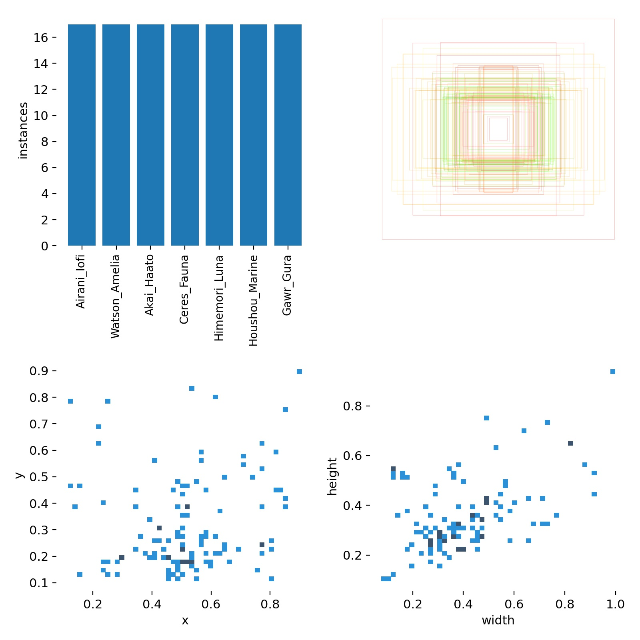

In [16]:
download_and_save(file_path="/content/yolov5/runs/train/exp/labels.jpg",
                  pretrained_model=pretrained_model,
                  download_file=True,
                  plot=True,
                  scale=0.4)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

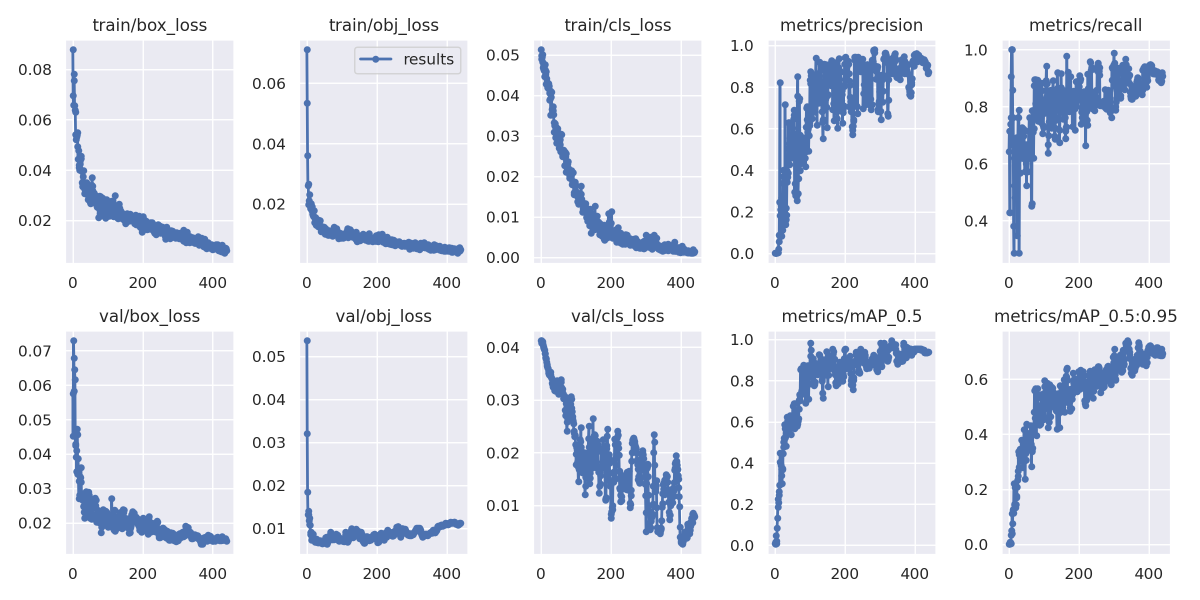

In [17]:
download_and_save(file_path="/content/yolov5/runs/train/exp/results.png",
                  pretrained_model=pretrained_model,
                  download_file=True,
                  plot=True,
                  scale=0.5
                  # save_to_drive=True,
                  # drive_save_path=drive_path_today)
                  )

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

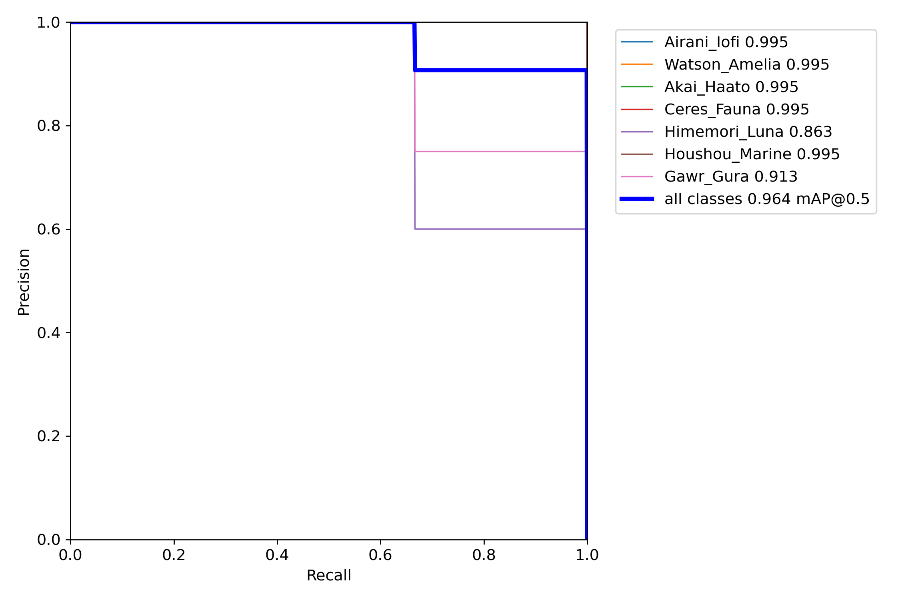

In [18]:
download_and_save(file_path="/content/yolov5/runs/train/exp/PR_curve.png",
                  pretrained_model=pretrained_model,
                  download_file=True,
                  plot=True,
                  scale=0.4)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

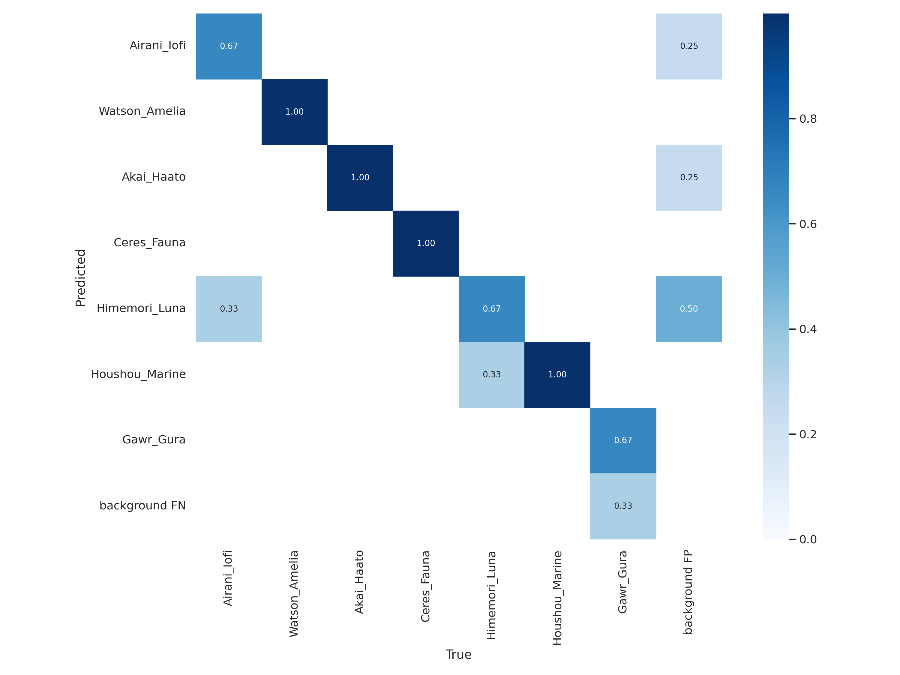

In [19]:
download_and_save(file_path="/content/yolov5/runs/train/exp/confusion_matrix.png",
                  pretrained_model=pretrained_model,
                  download_file=True,
                  plot=True,
                  scale=0.3)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

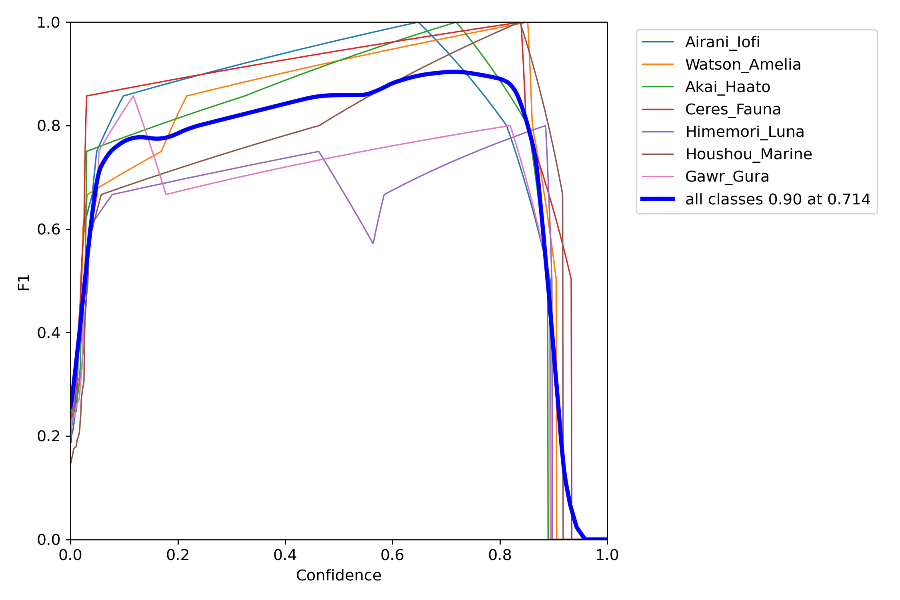

In [20]:
download_and_save(file_path="/content/yolov5/runs/train/exp/F1_curve.png",
                  pretrained_model=pretrained_model,
                  download_file=True,
                  plot=True,
                  scale=0.4)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

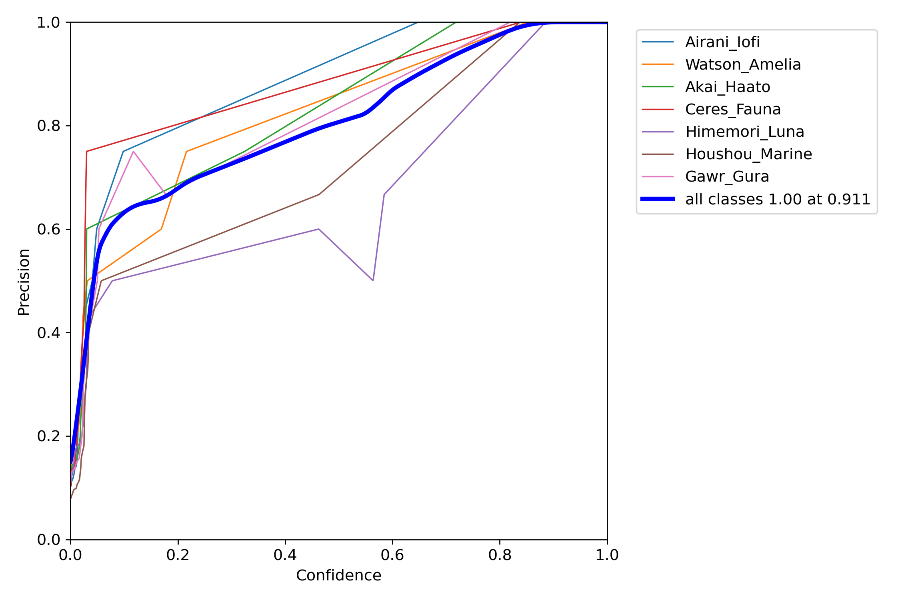

In [21]:
download_and_save(file_path="/content/yolov5/runs/train/exp/P_curve.png",
                  pretrained_model=pretrained_model,
                  download_file=True,
                  plot=True,
                  scale=0.4)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

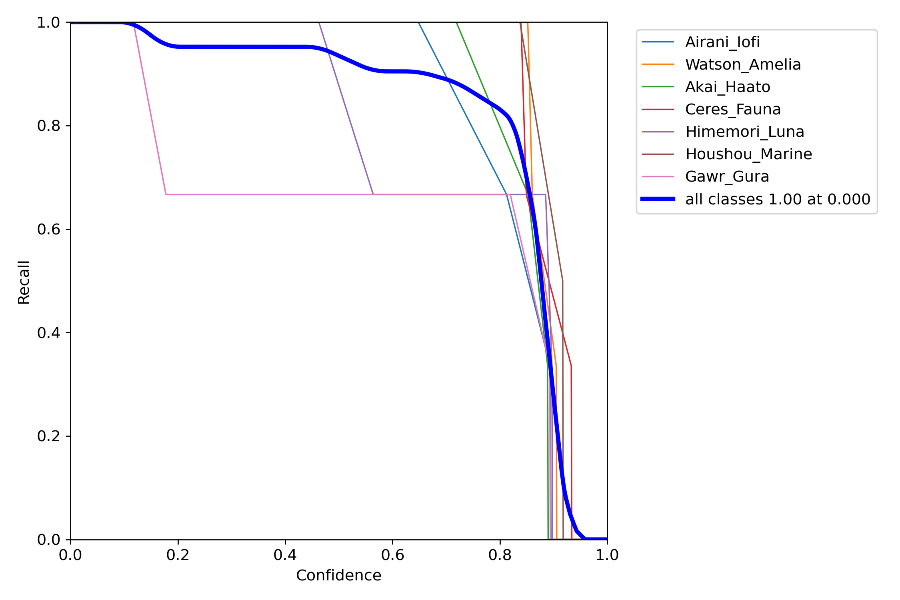

In [22]:
download_and_save(file_path="/content/yolov5/runs/train/exp/R_curve.png",
                  pretrained_model=pretrained_model,
                  download_file=True,
                  plot=True,
                  scale=0.4)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

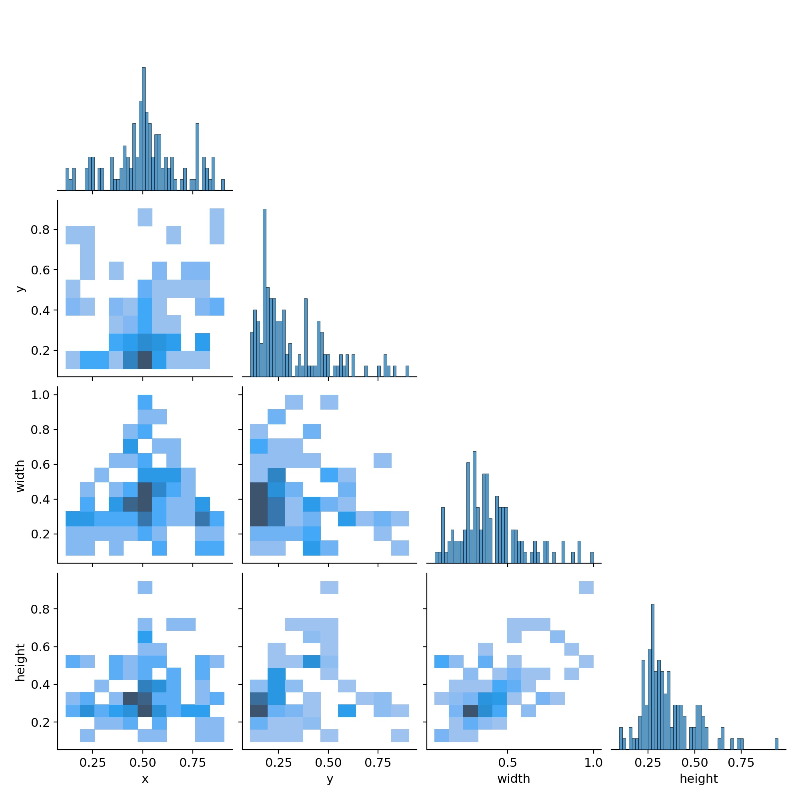

In [23]:
download_and_save(file_path="/content/yolov5/runs/train/exp/labels_correlogram.jpg",
                  pretrained_model=pretrained_model,
                  download_file=True,
                  plot=True,
                  scale=0.4)

# Test Model

detect: weights=['/content/yolov5/2022.06.22/2022.06.22-YOLOv5x6_1280-Hololive_Waifu_Classification.pt'], source=https://pbs.twimg.com/media/FV3TVGfUUAAa3ay.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
100% 93.2k/93.2k [00:00<00:00, 4.18MB/s]
YOLOv5 🚀 v6.1-259-ga2a1ed2 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
Model summary: 574 layers, 140028544 parameters, 0 gradients
image 1/1 /content/yolov5/FV3TVGfUUAAa3ay.jpg: 384x640 1 Airani_Iofi, Done. (0.031s)
Speed: 0.4ms pre-process, 30.6ms inference, 1.2ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp


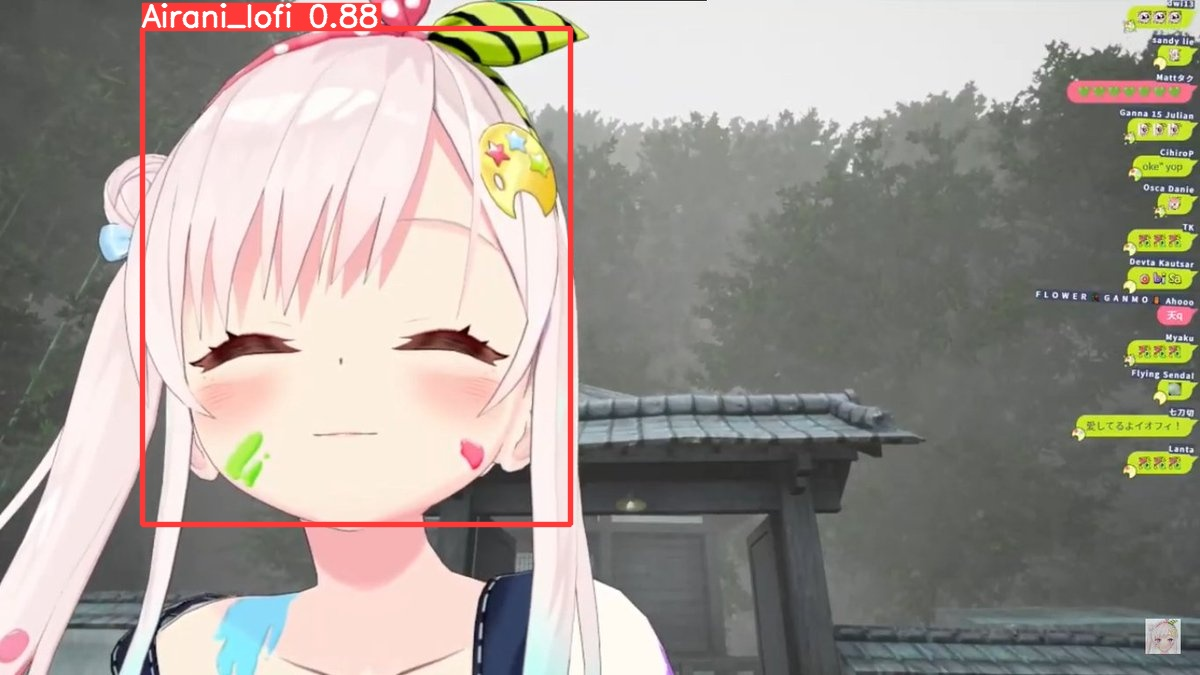

In [24]:
exp, file_path = gen_image_path(url='https://pbs.twimg.com/media/FV3TVGfUUAAa3ay.jpg',
                                exp=exp, 
                                pretrained_model=pretrained_model)
Image(filename=file_path, width=600)

detect: weights=['/content/yolov5/2022.06.22/2022.06.22-YOLOv5x6_1280-Hololive_Waifu_Classification.pt'], source=https://pbs.twimg.com/media/E3UZ7LMVEAEKZwA.png, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
100% 211k/211k [00:00<00:00, 7.56MB/s]
YOLOv5 🚀 v6.1-259-ga2a1ed2 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
Model summary: 574 layers, 140028544 parameters, 0 gradients
image 1/1 /content/yolov5/E3UZ7LMVEAEKZwA.png: 384x640 1 Himemori_Luna, Done. (0.034s)
Speed: 0.4ms pre-process, 33.8ms inference, 1.3ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp2


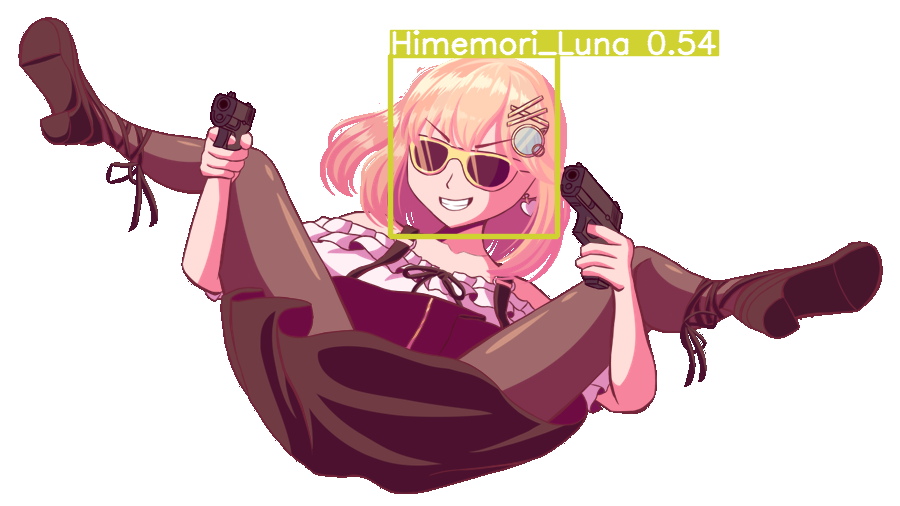

In [25]:
exp, file_path = gen_image_path(url='https://pbs.twimg.com/media/E3UZ7LMVEAEKZwA.png',
                                exp=exp, 
                                pretrained_model=pretrained_model)
Image(filename=file_path, width=600)

detect: weights=['/content/yolov5/2022.06.22/2022.06.22-YOLOv5x6_1280-Hololive_Waifu_Classification.pt'], source=https://pbs.twimg.com/media/FVTILOsUAAAmOFa.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
100% 98.3k/98.3k [00:00<00:00, 6.30MB/s]
YOLOv5 🚀 v6.1-259-ga2a1ed2 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
Model summary: 574 layers, 140028544 parameters, 0 gradients
image 1/1 /content/yolov5/FVTILOsUAAAmOFa.jpg: 448x640 1 Akai_Haato, Done. (0.038s)
Speed: 0.5ms pre-process, 37.7ms inference, 1.2ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp3


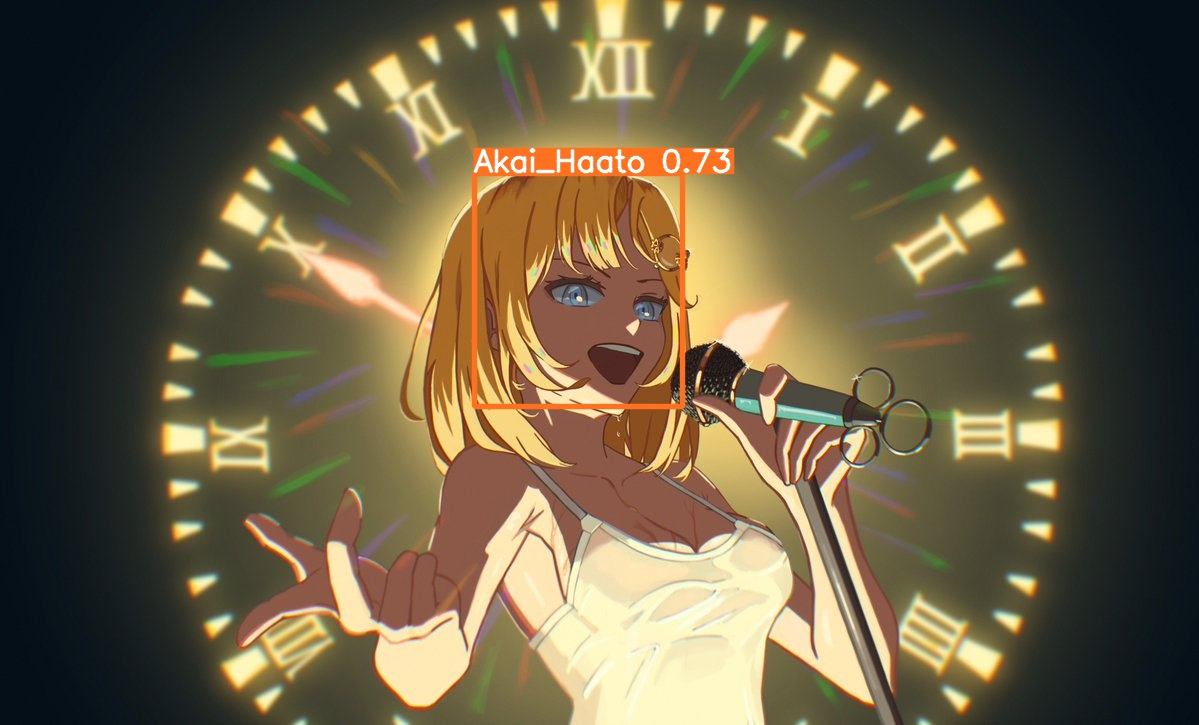

In [26]:
exp, file_path = gen_image_path(url='https://pbs.twimg.com/media/FVTILOsUAAAmOFa.jpg',
                                exp=exp, 
                                pretrained_model=pretrained_model)
Image(filename=file_path, width=600)

detect: weights=['/content/yolov5/2022.06.22/2022.06.22-YOLOv5x6_1280-Hololive_Waifu_Classification.pt'], source=https://pbs.twimg.com/media/FVpa1kTagAEnTDq.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
100% 124k/124k [00:00<00:00, 5.16MB/s]
YOLOv5 🚀 v6.1-259-ga2a1ed2 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
Model summary: 574 layers, 140028544 parameters, 0 gradients
image 1/1 /content/yolov5/FVpa1kTagAEnTDq.jpg: 640x320 1 Akai_Haato, Done. (0.038s)
Speed: 0.4ms pre-process, 38.1ms inference, 1.2ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp4


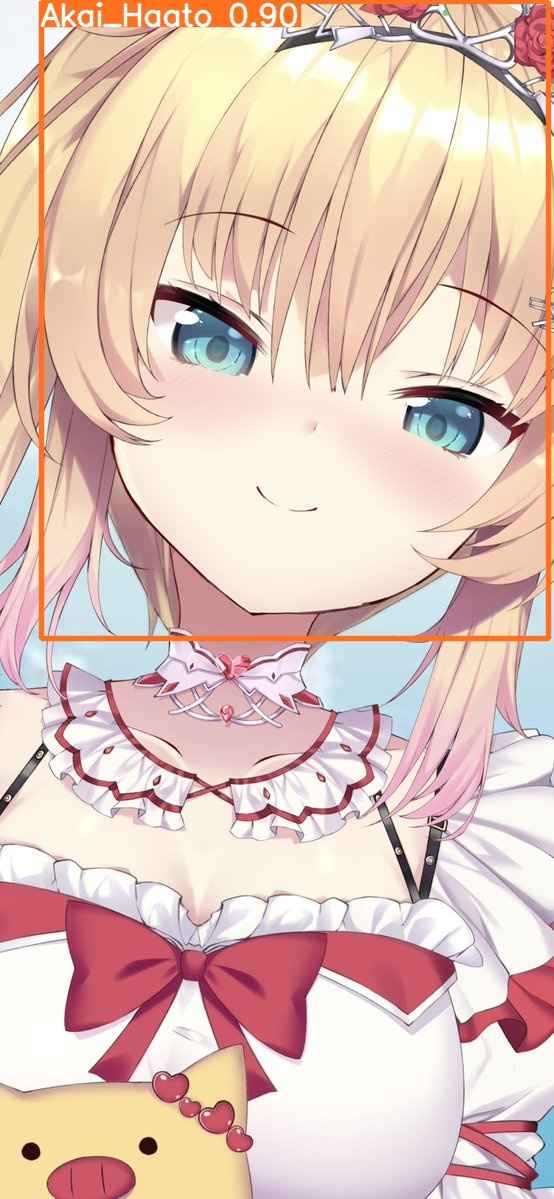

In [27]:
exp, file_path = gen_image_path(url='https://pbs.twimg.com/media/FVpa1kTagAEnTDq.jpg',
                                exp=exp, 
                                pretrained_model=pretrained_model)
Image(filename=file_path, width=600)

detect: weights=['/content/yolov5/2022.06.22/2022.06.22-YOLOv5x6_1280-Hololive_Waifu_Classification.pt'], source=https://pbs.twimg.com/media/FVlYJR5VEAEEFxN.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
100% 170k/170k [00:00<00:00, 6.52MB/s]
YOLOv5 🚀 v6.1-259-ga2a1ed2 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
Model summary: 574 layers, 140028544 parameters, 0 gradients
image 1/1 /content/yolov5/FVlYJR5VEAEEFxN.jpg: 640x448 1 Ceres_Fauna, Done. (0.031s)
Speed: 0.5ms pre-process, 30.9ms inference, 1.2ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp5


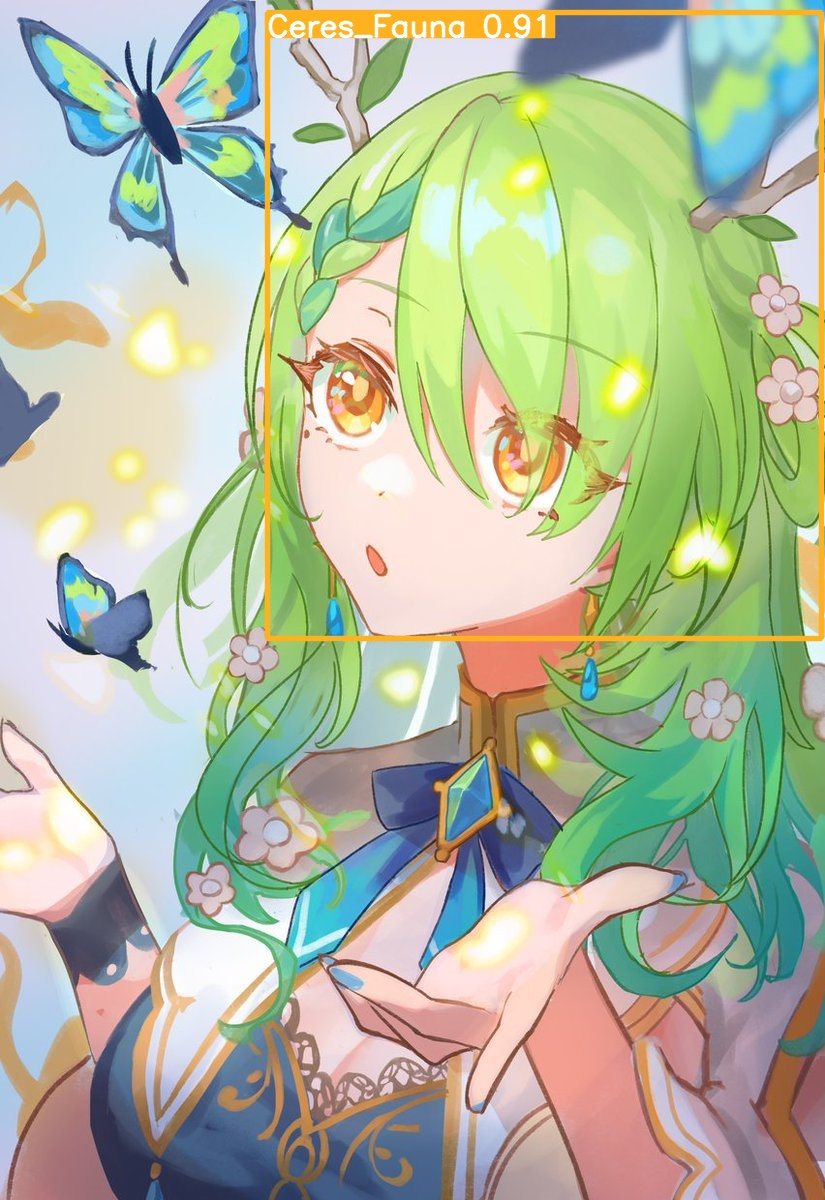

In [28]:
exp, file_path = gen_image_path(url='https://pbs.twimg.com/media/FVlYJR5VEAEEFxN.jpg',
                                exp=exp, 
                                pretrained_model=pretrained_model)
Image(filename=file_path, width=600)

detect: weights=['/content/yolov5/2022.06.22/2022.06.22-YOLOv5x6_1280-Hololive_Waifu_Classification.pt'], source=https://pbs.twimg.com/media/FVCUXj0UsAAP02y.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
100% 78.5k/78.5k [00:00<00:00, 5.56MB/s]
YOLOv5 🚀 v6.1-259-ga2a1ed2 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
Model summary: 574 layers, 140028544 parameters, 0 gradients
image 1/1 /content/yolov5/FVCUXj0UsAAP02y.jpg: 320x640 Done. (0.029s)
Speed: 0.4ms pre-process, 29.1ms inference, 0.3ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp6


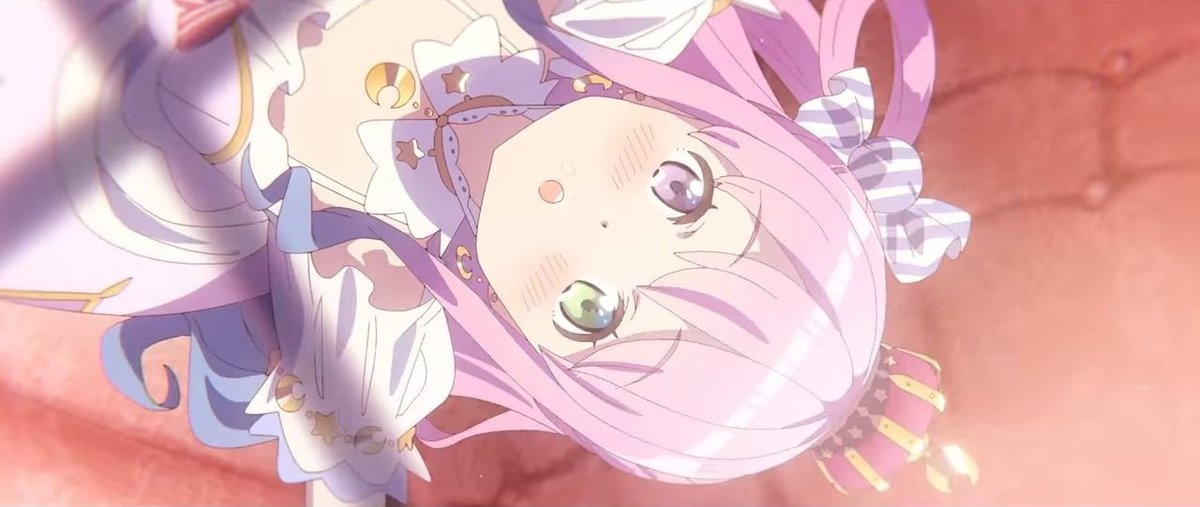

In [29]:
exp, file_path = gen_image_path(url='https://pbs.twimg.com/media/FVCUXj0UsAAP02y.jpg',
                                exp=exp, 
                                pretrained_model=pretrained_model)
Image(filename=file_path, width=600)

detect: weights=['/content/yolov5/2022.06.22/2022.06.22-YOLOv5x6_1280-Hololive_Waifu_Classification.pt'], source=https://pbs.twimg.com/media/FT6fewfagAALPi1.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
100% 144k/144k [00:00<00:00, 5.53MB/s]
YOLOv5 🚀 v6.1-259-ga2a1ed2 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
Model summary: 574 layers, 140028544 parameters, 0 gradients
image 1/1 /content/yolov5/FT6fewfagAALPi1.jpg: 384x640 1 Himemori_Luna, Done. (0.031s)
Speed: 0.4ms pre-process, 30.6ms inference, 1.2ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp7


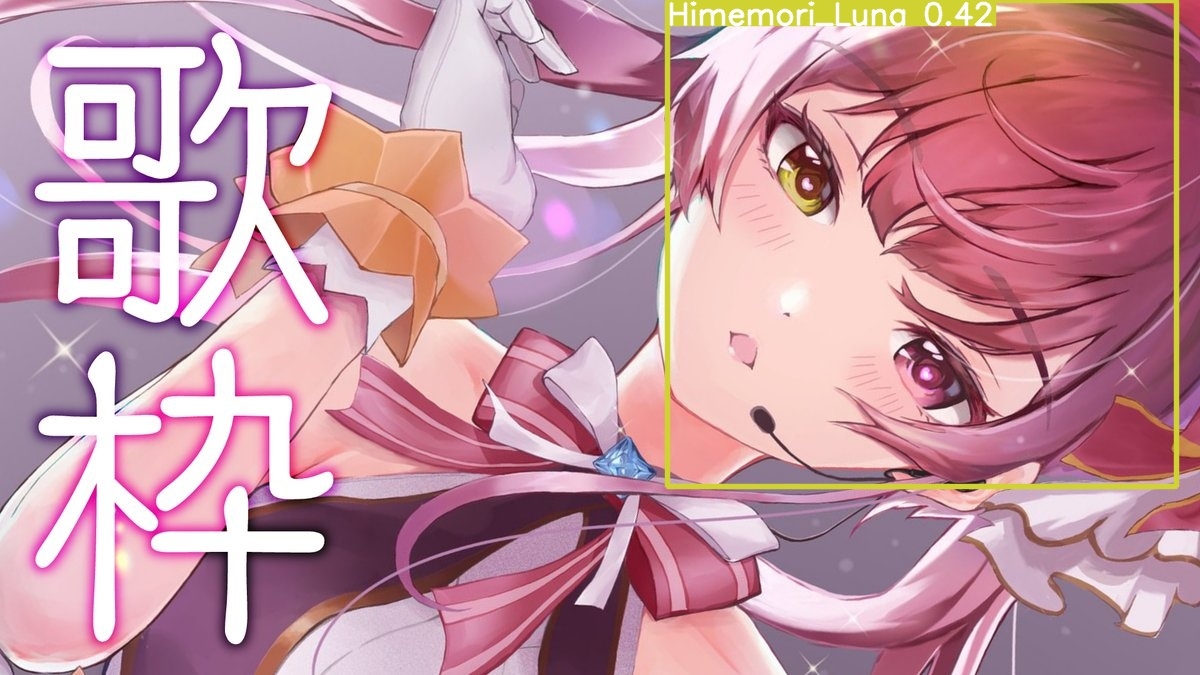

In [30]:
exp, file_path = gen_image_path(url='https://pbs.twimg.com/media/FT6fewfagAALPi1.jpg',
                                exp=exp, 
                                pretrained_model=pretrained_model)
Image(filename=file_path, width=600)

detect: weights=['/content/yolov5/2022.06.22/2022.06.22-YOLOv5x6_1280-Hololive_Waifu_Classification.pt'], source=https://pbs.twimg.com/media/FVoeae6akAEG-23.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
100% 101k/101k [00:00<00:00, 6.45MB/s]
YOLOv5 🚀 v6.1-259-ga2a1ed2 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
Model summary: 574 layers, 140028544 parameters, 0 gradients
image 1/1 /content/yolov5/FVoeae6akAEG-23.jpg: 640x512 2 Gawr_Guras, Done. (0.032s)
Speed: 0.5ms pre-process, 32.0ms inference, 1.2ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp8


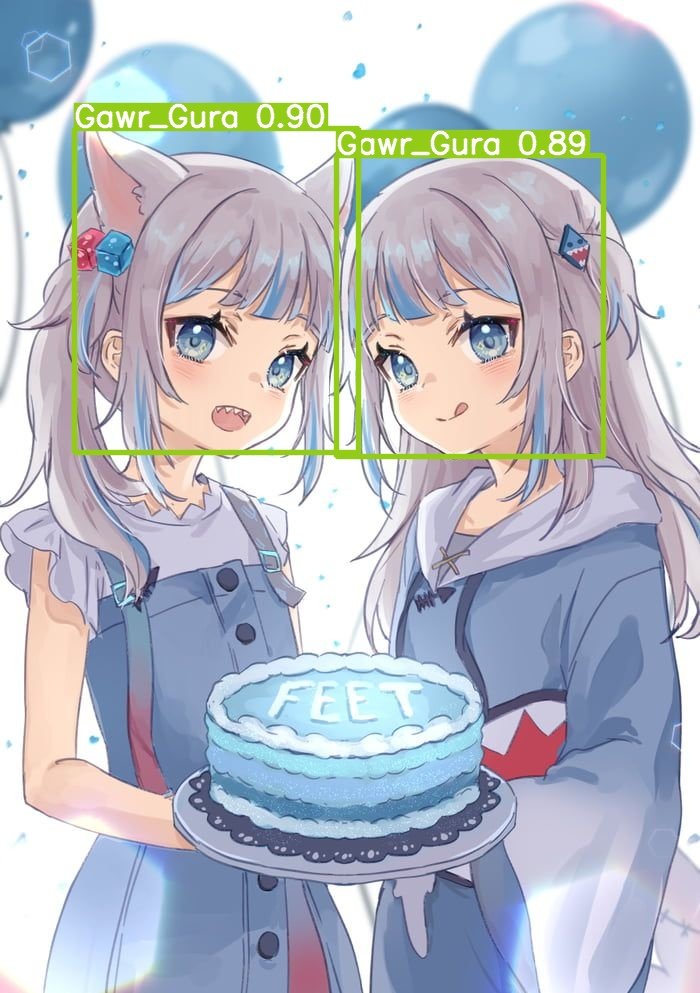

In [31]:
exp, file_path = gen_image_path(url='https://pbs.twimg.com/media/FVoeae6akAEG-23.jpg',
                                exp=exp, 
                                pretrained_model=pretrained_model)
Image(filename=file_path, width=600)

In [32]:
# exp, file_path = gen_image_path(url='',
#                                 exp=exp, 
#                                 pretrained_model=pretrained_model)
# Image(filename=file_path, width=600)

In [33]:
# exp, file_path = gen_image_path(url='',
#                                 exp=exp, 
#                                 pretrained_model=pretrained_model)
# Image(filename=file_path, width=600)

# 16. Sleeping

In [ ]:
sleep = 0

while(True):
  time.sleep(1)
  sleep += 1
  print("", end=f"\rSleeping... {int_to_str(sleep)}")

Sleeping... 03h09m13s